# 04 - Değerlendirme

Adım 4: dört anomali katmanı (column, multivariate, entity, temporal) ayrı ayrı skor üretir.
Dedektörler etiketsiz (unsupervised) çalışır; `isFraud` sadece burada ölçüm için kullanılır.

Zaman bazlı bölme (karıştırmadan): ilk %60 train, %60-80 valid, son %20 test.
Tasarım kararları valid'de verilir; test sadece final rapor içindir. Skorlar `python scripts/train.py` ile üretilir.

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve

from fraud_platform.config import PROJECT_ROOT, get_settings
from fraud_platform.detection.factory import LAYERS, load_detectors
from fraud_platform.evaluation import metrics_table

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
IMG = PROJECT_ROOT / "docs" / "images"

settings = get_settings()
ID, TARGET, TIME = settings.data.id_column, settings.data.target_column, settings.data.time_column
ALERT = settings.evaluation.alert_rate

scores = pd.read_parquet(settings.layer_scores_path)
scores.groupby("split", observed=True)[TARGET].agg(işlem="size", fraud_oranı="mean").round(4)

,işlem,fraud_oranı
split,,
train,354324,0.0338
valid,118108,0.0390
test,118108,0.0344


## 1. Katman bazında performans

In [2]:
valid = scores[scores["split"] == "valid"]
test = scores[scores["split"] == "test"]
cols = ["roc_auc", "pr_auc", f"at_{ALERT:.0%}_precision", f"at_{ALERT:.0%}_recall"]

valid_tbl = metrics_table(valid, [f"{l}_valfit" for l in LAYERS], TARGET, ALERT)[cols]
valid_tbl.index = list(LAYERS)
test_tbl = metrics_table(test, list(LAYERS), TARGET, ALERT)[cols]
pd.concat({"valid (train'de fit)": valid_tbl, "test (train+valid'de fit)": test_tbl}, axis=1).round(4)

valid (train'de fit)                                       \
                          roc_auc  pr_auc at_3%_precision at_3%_recall   
column                     0.7636  0.2205          0.3167       0.2433   
multivariate               0.7768  0.1550          0.2467       0.1895   
entity                     0.6886  0.0916          0.1406       0.1080   
temporal                   0.6569  0.0896          0.1372       0.1054   

             test (train+valid'de fit)                                       
                               roc_auc  pr_auc at_3%_precision at_3%_recall  
column                          0.7510  0.1199          0.2154       0.1877  
multivariate                    0.7670  0.0996          0.1039       0.0906  
entity                          0.6734  0.0777          0.1250       0.1090  
temporal                        0.6356  0.0552          0.0607       0.0529

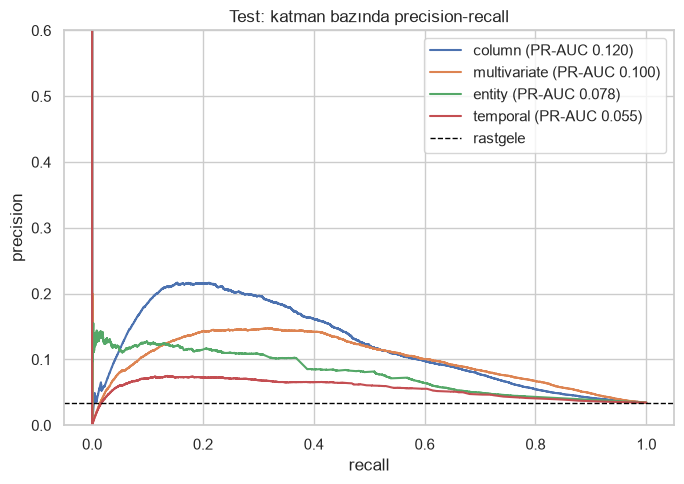

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
for layer in LAYERS:
    p, r, _ = precision_recall_curve(test[TARGET], test[layer])
    ax.plot(r, p, label=f"{layer} (PR-AUC {test_tbl.loc[layer, 'pr_auc']:.3f})")
ax.axhline(test[TARGET].mean(), color="black", ls="--", lw=1, label="rastgele")
ax.set(title="Test: katman bazında precision-recall", xlabel="recall", ylabel="precision", ylim=(0, 0.6))
ax.legend()
plt.tight_layout()
fig.savefig(IMG / "04_layer_pr_curves.png", dpi=120)

Valid -> test düşüşü: aynı dedektör daha fazla veriyle fit edilmesine rağmen PR-AUC düşüyor. Sebep zaman kayması (drift):
fraud oranı ve örüntüsü aylara göre değişiyor (Aralık %2,6, Ocak-Mart %4,0, Nisan-Mayıs ~%3,5). ROC daha kararlı, yani sıralama yeteneği
büyük ölçüde korunuyor; düşen, en üstteki alarmların isabeti.

> **Yorum:** En güçlü tek katman column: testte en riskli %3'e alarm verince isabet %21,5, rastgele seçimin (%3,4) ~6 katı. Multivariate
> ROC'ta en iyi (0,767) ama alarm bölgesinde zayıflıyor. Valid'den teste her katmanda PR-AUC düşüyor (column 0,221 -> 0,120) ama
> ROC çok az değişiyor (0,764 -> 0,751). Yani modeller işlemleri hâlâ doğru sıralıyor; bozulan, en tepedeki alarmların isabeti.
> Bunu drift olarak yorumluyorum: fraud oranı ve örüntüsü aylara göre değişiyor. Üretimde düzenli yeniden eğitim ve skor dağılımı
> izleme gerekir.

## 2. Katmanlar farklı şeyler mi görüyor?

Çok katmanlı mimarinin gerekçesi: katmanlar aynı işlemleri işaretliyorsa birleştirmenin faydası yoktur.

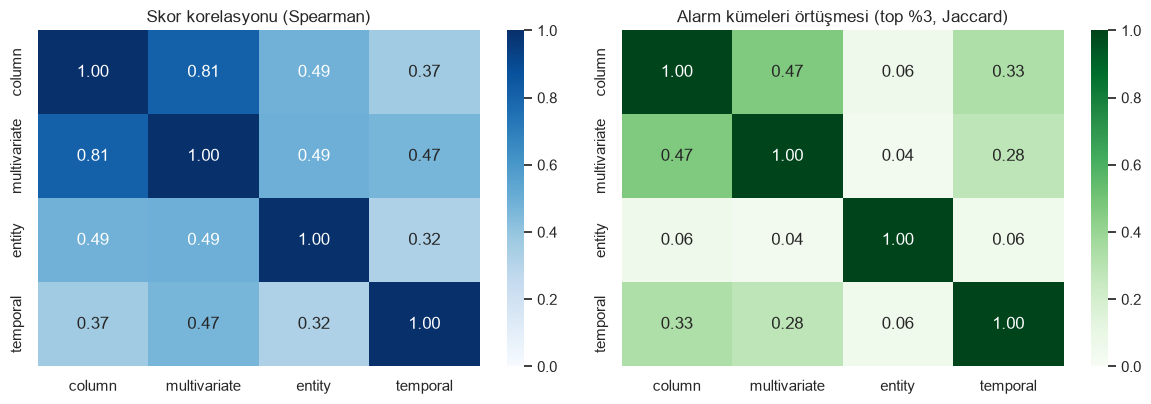

In [4]:
corr = test[list(LAYERS)].corr(method="spearman")

n_alert = int(len(test) * ALERT)
alerts = {l: set(test.nlargest(n_alert, l)[ID]) for l in LAYERS}
jac = pd.DataFrame({a: {b: len(alerts[a] & alerts[b]) / len(alerts[a] | alerts[b]) for b in LAYERS} for a in LAYERS})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[0])
axes[0].set_title("Skor korelasyonu (Spearman)")
sns.heatmap(jac, annot=True, fmt=".2f", cmap="Greens", vmin=0, vmax=1, ax=axes[1])
axes[1].set_title(f"Alarm kümeleri örtüşmesi (top %{ALERT * 100:.0f}, Jaccard)")
plt.tight_layout()
fig.savefig(IMG / "04_layer_overlap.png", dpi=120)

In [5]:
# her fraud'u kaç katman alarm listesine aldı; sadece tek katmanın yakaladığı fraud'lar
fraud_ids = set(test.loc[test[TARGET] == 1, ID])
caught_by = pd.Series({fid: [l for l in LAYERS if fid in alerts[l]] for fid in fraud_ids})
n_layers = caught_by.map(len)
print("fraud sayısı:", len(fraud_ids))
print("en az bir katmanın alarmında:", int((n_layers > 0).sum()), f"({(n_layers > 0).mean():.1%})")
print("tek bir katmanın alarmında olanlar:")
print(caught_by[n_layers == 1].map(lambda x: x[0]).value_counts().to_string())

fraud sayısı: 4064
en az bir katmanın alarmında: 1210 (29.8%)
tek bir katmanın alarmında olanlar:
column          311
entity          214
multivariate    119
temporal         77


> **Yorum:** Column ile multivariate benzer işlemleri işaretliyor (Spearman 0,81), entity ve temporal diğerlerinden belirgin farklı
> (0,32-0,49). Alarm listelerinde fark daha net: entity'nin en riskli %3'ü diğer katmanlarınkiyle sadece %4-6 örtüşüyor. Testteki
> 4.064 fraud'un 1.210'u en az bir katmanın alarm listesinde ve 721'ini sadece tek bir katman yakalıyor (column 311, entity 214,
> multivariate 119, temporal 77). Yani hangi katmanı çıkarsam bir grup fraud'u kaybediyorum; katmanları birleştirmenin gerekçesi bu.

## 3. Gerçek zamanlı skorlama: train/serve tutarlılığı

API'ye tek işlem gelir. Profil deposu (`EntityProfileStore`) kullanıcının ve cihazın geçmiş işlemlerini tutar; yeni işlem
bu geçmişin sonuna eklenip aynı feature pipeline'dan geçer (`OnlineFeatureBuilder`). Test döneminden 200 rastgele işlem
tek tek bu yolla hesaplanıp toplu hesapla karşılaştırılıyor.

In [6]:
import time

from fraud_platform.features.online import OnlineFeatureBuilder
from fraud_platform.features.pipeline import FeaturePipeline
from fraud_platform.store.profile_store import EntityProfileStore

pipeline = FeaturePipeline.load(settings.feature_pipeline_path)
store = EntityProfileStore.load(settings.profile_store_path)
online = OnlineFeatureBuilder(pipeline, store)

features = pd.read_parquet(settings.features_path).set_index(ID)
merged = pd.read_parquet(settings.merged_path)
sample_ids = test[ID].sample(200, random_state=1)
raw = merged[merged[ID].isin(sample_ids)]

start = time.time()
got = online.build(raw).set_index(ID)
elapsed = time.time() - start
expected = features.loc[got.index]

diff = {}
for f in pipeline.feature_names:
    a, b = got[f], expected[f]
    same = (a.isna() & b.isna()) | (a == b).fillna(False)
    if a.dtype.kind in "fi":
        same |= (a.astype(float) - b.astype(float)).abs().le(1e-9)
    diff[f] = int((~same).sum())

print(f"{len(got)} işlem, işlem başına {elapsed / len(got) * 1000:.0f} ms")
print("farklı çıkan feature sayısı:", sum(v > 0 for v in diff.values()), "/", len(diff))

200 işlem, işlem başına 61 ms
farklı çıkan feature sayısı: 0 / 55


> **Yorum:** API'ye tek bir işlem geldiğinde entity ve velocity feature'ları için kullanıcının geçmişi gerekiyor. Ayrı bir canlı hesap formülü
> yazmak yerine profil deposundaki geçmişin sonuna yeni işlemi ekleyip aynı pipeline'dan geçiriyorum. Test döneminden 200 rastgele
> işlemi tek tek bu yolla hesapladım: 55 feature'ın hiçbirinde toplu hesaptan fark yok, işlem başına ~60 ms. Eğitimde ve canlıda
> aynı kod çalıştığı için train/serve tutarsızlığı tasarım gereği oluşmuyor.

## 4. Açıklanabilirlik: bir fraud işlemi dört katmandan

In [7]:
detectors = load_detectors(settings.detectors_path)
top_fraud = test[test[TARGET] == 1].assign(total=lambda x: x[list(LAYERS)].rank(pct=True).mean(axis=1))
tx_id = top_fraud.nlargest(1, "total")[ID].iloc[0]
row = features.loc[[tx_id]].reset_index()

print(f"TransactionID {tx_id}")
for det in detectors:
    s = test.loc[test[ID] == tx_id, det.name].iloc[0]
    pct = (test[det.name] <= s).mean() * 100
    print(f"\n[{det.name}] ham skor {s:.4f} (testte %{pct:.1f} yüzdelik)")
    for r in det.explain(row)[0]:
        print(f"   - {r.text}")

TransactionID 3554906

[column] ham skor 0.2347 (testte %99.7 yüzdelik)
   - id_13 = 27.0 eğitimde hiç görülmemiş bir değer
   - V290 = 6, tipik değerden 39.1 robust-z uzakta (medyan 1)
   - V303 = 4, tipik değerden 11.2 robust-z uzakta (medyan 0)

[multivariate] ham skor 0.6250 (testte %98.2 yüzdelik)
   - V302 = 4; eğitimde işlemlerin sadece %0.1'i bu kadar yüksek
   - V52 = 4; eğitimde işlemlerin sadece %0.1'i bu kadar yüksek
   - V47 = 4; eğitimde işlemlerin sadece %0.1'i bu kadar yüksek

[entity] ham skor 0.4345 (testte %96.3 yüzdelik)
   - Geçmişi olan kullanıcı bu cihazı ilk kez kullanıyor
   - Kullanıcı daha önce 5 farklı cihaz kullanmış
   - Bu cihazda daha önce 1 farklı kullanıcı görülmüş

[temporal] ham skor 0.6516 (testte %98.5 yüzdelik)
   - Önceki işlemden 7.8 dakika sonra
   - Kullanıcının son 24 saatte 10 işlemi daha var
   - Son 24 saatte toplam 1107.87 USD harcama (kullanıcı ortalamasının 9.9 katı)


## 5. Skor birleştirme (Adım 5)

Dört skor farklı ölçeklerde. Önce normalize edilip sonra ağırlıklı toplanıyor. Kararlar valid dönemi ikiye bölünerek verildi:
valid-A (ilk yarı) veriye dayalı ağırlıkları bulmak için, valid-B (ikinci yarı) tüm seçenekleri adil kıyaslamak için.
Normalizasyon referansı: doğrulama turundaki dedektörlerin train skorları (üretimdeki gibi: eğitimde fit, yeni veride uygula).

In [8]:
import itertools

from sklearn.metrics import average_precision_score, roc_auc_score

from fraud_platform.config import ScoringConfig
from fraud_platform.detection.aggregator import ScoreAggregator
from fraud_platform.evaluation import alert_metrics

ref = scores[scores["split"] == "train"][[f"{l}_valfit" for l in LAYERS]]
ref.columns = list(LAYERS)
va = scores[scores["split"] == "valid"].sort_values(TIME)
vA, vB = va.iloc[: len(va) // 2], va.iloc[len(va) // 2:]

def layer_frame(df):
    out = df[[f"{l}_valfit" for l in LAYERS]].copy()
    out.columns = list(LAYERS)
    return out

def evaluate(y, score):
    score = pd.Series(np.asarray(score, dtype=float), index=y.index)
    m = alert_metrics(y, score, ALERT)
    return {"pr_auc": average_precision_score(y, score), "roc_auc": roc_auc_score(y, score),
            "precision@3%": m["precision"], "recall@3%": m["recall"]}

equal = {l: 1.0 for l in LAYERS}
norm_rows = {}
for method in ["percentile", "minmax", "tail_log"]:
    agg = ScoreAggregator(ScoringConfig(normalization=method, weights=equal)).fit(ref)
    norm_rows[method] = evaluate(vB[TARGET], agg.transform(layer_frame(vB))["raw_anomaly_score"])
pd.DataFrame(norm_rows).T.round(4)

,pr_auc,roc_auc,precision@3%,recall@3%
percentile,0.1370,0.7638,0.2015,0.1732
minmax,0.1580,0.7711,0.2269,0.1951
tail_log,0.1703,0.7726,0.2438,0.2096


Normalizasyon: en basit yöntem olan düz yüzdelik en kötü çıktı. Yüzdelik kuyruğu sıkıştırıyor: bir katmanın "%99,99 uç" dediği işlemle
"%99 uç" dediği işlem arasındaki fark 0,99-1,0 arasında kayboluyor; fraud'lar tam bu kuyrukta. Kuyruk-log dönüşümü
`-log10(1 - yüzdelik)` kuyruğu açıyor (%99 -> 2, %99,99 -> 4); p-değerlerini log ölçekte birleştiren Fisher yöntemine benzer.

In [9]:
tail = ScoreAggregator(ScoringConfig(normalization="tail_log", weights=equal)).fit(ref)
def surprise(df):
    lf = layer_frame(df)
    return pd.DataFrame({l: tail.normalizers_[l](lf[l]) for l in LAYERS})

SA, SB = surprise(vA), surprise(vB)

def grid_search(S, y, step=0.05):
    best, best_w = -1, None
    for w in itertools.product(np.arange(0, 1 + 1e-9, step), repeat=len(LAYERS) - 1):
        last = 1 - sum(w)
        if last < -1e-9:
            continue
        ww = np.array([*w, max(last, 0)])
        v = average_precision_score(y, S.to_numpy() @ ww)
        if v > best:
            best, best_w = v, ww
    return dict(zip(LAYERS, best_w))

lift = {l: average_precision_score(vA[TARGET], SA[l]) / vA[TARGET].mean() - 1 for l in LAYERS}
proportional = {l: v / sum(lift.values()) for l, v in lift.items()}
options = {
    "eşit": equal,
    "sezgisel (c.15 m.35 e.30 t.20)": {"column": .15, "multivariate": .35, "entity": .30, "temporal": .20},
    "performansa orantılı (seçilen)": proportional,
    "grid optimum (valid-A)": grid_search(SA, vA[TARGET]),
}
rows = {}
for name, w in options.items():
    wv = np.array([w[l] for l in LAYERS]) / sum(w.values())
    rows[name] = {**{f"w_{l}": round(x, 3) for l, x in zip(LAYERS, wv)}, **evaluate(vB[TARGET], SB.to_numpy() @ wv)}
rows["max (en yüksek katman)"] = evaluate(vB[TARGET], SB.max(axis=1))
for l in LAYERS:
    rows[f"tek katman: {l}"] = evaluate(vB[TARGET], SB[l])
pd.DataFrame(rows).T.round(4)

,w_column,w_multivariate,w_entity,w_temporal,pr_auc,roc_auc,precision@3%,recall@3%
eşit,0.250,0.250,0.250,0.250,0.1703,0.7726,0.2438,0.2096
sezgisel (c.15 m.35 e.30 t.20),0.150,0.350,0.300,0.200,0.1634,0.7735,0.2319,0.1994
performansa orantılı (seçilen),0.424,0.293,0.124,0.158,0.1982,0.7761,0.2692,0.2314
grid optimum (valid-A),0.850,0.000,0.150,0.000,0.2174,0.7552,0.2771,0.2382
max (en yüksek katman),NaN,NaN,NaN,NaN,0.1520,0.7631,0.2280,0.1960
tek katman: column,NaN,NaN,NaN,NaN,0.2131,0.7519,0.2743,0.2358
tek katman: multivariate,NaN,NaN,NaN,NaN,0.1429,0.7753,0.2252,0.1936
tek katman: entity,NaN,NaN,NaN,NaN,0.0865,0.6785,0.1507,0.1295
tek katman: temporal,NaN,NaN,NaN,NaN,0.0631,0.6421,0.0954,0.0820


In [10]:
# grid optimumu zaman içinde kararlı mı? valid 4 zaman dilimine bölünüp her dilimde ayrı aranıyor
n = len(va)
stability = {}
for i in range(4):
    chunk = va.iloc[i * n // 4: (i + 1) * n // 4]
    stability[f"dilim {i}"] = {**grid_search(surprise(chunk), chunk[TARGET], step=0.1),
                               "fraud_oranı": chunk[TARGET].mean()}
pd.DataFrame(stability).T.round(3)

,column,multivariate,entity,temporal,fraud_oranı
dilim 0,0.7,0.1,0.2,0.0,0.039
dilim 1,0.7,0.0,0.1,0.2,0.048
dilim 2,0.6,0.2,0.2,0.0,0.035
dilim 3,0.8,0.0,0.2,0.0,0.035


Ağırlık kararı: performansa orantılı (`settings.yaml -> scoring.weights`). Her katmanın valid-A'daki tek başına PR-AUC kazancına
(PR / fraud oranı - 1) orantılı. Grid optimumu PR'de biraz daha yüksek ama multivariate ve temporal'ı sıfırlıyor (sadece onların yakaladığı
fraud'lar kaybolur) ve ROC düşüyor; dilimler arasında column hep baskın. Sezgisel ilk tahminim bu veride en zayıf ağırlıklı seçenek.

Dürüst bulgu: column katmanı tek başına PR-AUC'de birleşik skora yakın / biraz üstünde. Bu dört katmanın doğrusal birleşimi
PR'de column'a az şey ekliyor; kazanç ROC'ta (genel sıralama), açıklanabilirlikte ve Adım 6-7'nin katman skorlarını ayrı kullanabilmesinde.

> **Yorum:** Normalizasyonda en basit yöntem olan düz yüzdelik en kötü çıktı (PR 0,137); kuyruk-log en iyisi (0,170), çünkü fraud'ların
> bulunduğu kuyruğu açıyor. Ağırlıklarda grid optimumu PR'de en yüksek (0,217) ama multivariate ve temporal'ı sıfırlıyor ve ROC'u
> düşürüyor (0,755); sadece o katmanların yakaladığı fraud'ları kaybetmek istemedim. Dilim tablosu da grid ağırlıklarının zamanla
> oynadığını gösteriyor (temporal bir dilimde 0,2, diğerlerinde 0). Performansa orantılı ağırlık PR 0,198 ile ikinci, ROC 0,776
> ile en iyi; seçtiğim bu. Sezgisel ilk tahminim bu veride eşit ağırlıktan bile kötü (0,163). Dürüst bir bulgu da var: column tek
> başına (0,213) birleşik skora çok yakın; birleşimin kazancı PR'de değil, ROC'ta ve açıklanabilirlikte.

In [11]:
final_cols = [*LAYERS, "raw_anomaly_score"]
final_tbl = metrics_table(test, final_cols, TARGET, ALERT)[cols]
final_tbl.round(4)

,roc_auc,pr_auc,at_3%_precision,at_3%_recall
column,0.7510,0.1199,0.2154,0.1877
multivariate,0.7670,0.0996,0.1039,0.0906
entity,0.6734,0.0777,0.1250,0.1090
temporal,0.6356,0.0552,0.0607,0.0529
raw_anomaly_score,0.7663,0.1130,0.1840,0.1604


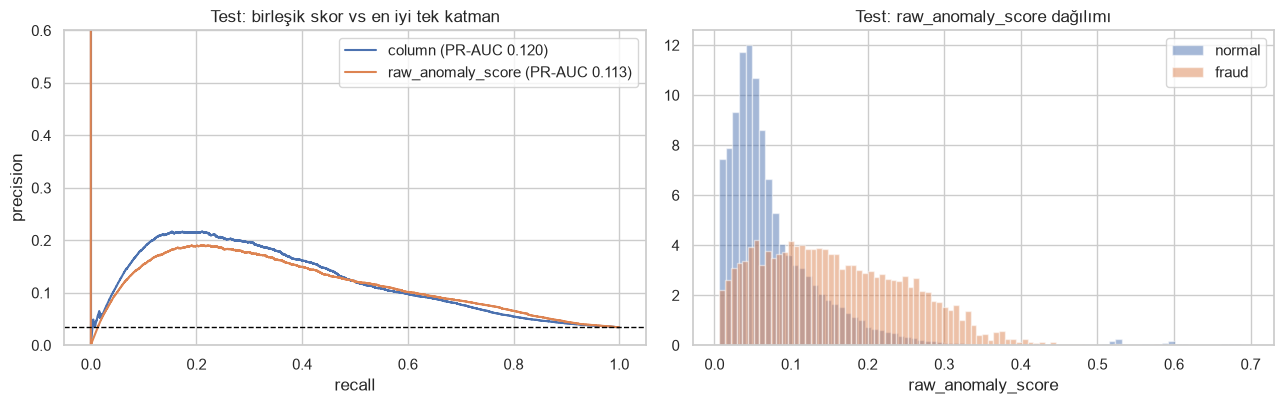

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for layer in ["column", "raw_anomaly_score"]:
    p, r, _ = precision_recall_curve(test[TARGET], test[layer])
    axes[0].plot(r, p, label=f"{layer} (PR-AUC {final_tbl.loc[layer, 'pr_auc']:.3f})")
axes[0].axhline(test[TARGET].mean(), color="black", ls="--", lw=1)
axes[0].set(title="Test: birleşik skor vs en iyi tek katman", xlabel="recall", ylabel="precision", ylim=(0, 0.6))
axes[0].legend()
for label, name in [(0, "normal"), (1, "fraud")]:
    axes[1].hist(test.loc[test[TARGET] == label, "raw_anomaly_score"], bins=80, alpha=0.5, density=True, label=name)
axes[1].set(title="Test: raw_anomaly_score dağılımı", xlabel="raw_anomaly_score")
axes[1].legend()
plt.tight_layout()
fig.savefig(IMG / "05_aggregation.png", dpi=120)

Örnek çıktı - `ScoringService` (Facade): ham işlem -> profil deposundan geçmiş -> aynı feature pipeline -> 4 dedektör -> birleştirici.
Aynı akış `python scripts/score_transaction.py <TransactionID>` ile komut satırından da çalışır (API öncesi ara kontrol).

In [13]:
from fraud_platform.services.scoring_service import ScoringService

from fraud_platform.context.adjuster import ContextAdjuster

service = ScoringService(online, detectors, ScoreAggregator.load(settings.aggregator_path),
                         ContextAdjuster(settings.context.rules_file), ID)
raw_tx = merged[merged[ID] == tx_id].drop(columns=TARGET)
result = service.score(raw_tx, explain=False)[0]
print(json.dumps(result, indent=2, ensure_ascii=False, default=str))

{
  "TransactionID": 3554906,
  "uid": "5812_NA_174",
  "layer_scores": {
    "column": 0.234729,
    "multivariate": 0.624996,
    "temporal": 0.651613,
    "entity": 0.434459
  },
  "layer_percentiles": {
    "column": 0.999662,
    "multivariate": 0.993025,
    "temporal": 0.993055,
    "entity": 0.948632
  },
  "raw_anomaly_score": 0.45934,
  "raw_percentile": 0.999567,
  "context_factor": 1.22,
  "adjusted_score": 0.560395,
  "risk_percentile": 0.99993,
  "context_adjustments": [
    {
      "id": "C02",
      "name": "gece",
      "category": "zaman",
      "factor": 1.22,
      "condition": "is_night = 1",
      "reason": "Yerel 00-06 arası hacim düşük, fraud oranı ~2,7 kat; temporal katmanın nadir saat bileşeni bunu zayıf yakalıyor"
    }
  ]
}


> **Yorum:** Testte ham birleşik skor PR'de column'un biraz altında (0,113 vs 0,120) ama ROC'ta üstünde (0,766 vs 0,751). Skor dağılımında
> fraud'lar sağa kaymış ama iki dağılım büyük ölçüde örtüşüyor; tek bir eşikle ayırmak zor, bu yüzden alarm bütçesiyle
> çalışıyorum. Örnek işlem (3554906) birleşik skorda %99,96 yüzdelikte ve dört katmanın hepsi uçta: column %99,97, multivariate ve
> temporal %99,3, entity %94,9. Aynı akış tek komutla (`score_transaction.py`) çalışıyor ve sonuç gerekçeleriyle geliyor.

## 6. Context adjust engine (Adım 6)

İstatistiksel olarak tuhaf olan her işlem iş açısından riskli değildir; tersine, skorun göremediği riskler de vardır.
Context kuralları ham skoru bir çarpanla düzeltir: `adjusted_score = min(raw x sınırlı(Π çarpan), 1)`.
Kurallar `config/context_rules.yaml`'da; her kuralda koşul, çarpan, gerekçe ve kalibrasyon kanıtı (`evidence`) var.

In [14]:
from fraud_platform.conditions.evaluator import describe
from fraud_platform.context.adjuster import ContextAdjuster
from fraud_platform.context.calibration import calibrate

adjuster = ContextAdjuster(settings.context.rules_file)
rs = adjuster.ruleset
print(f"toplam çarpan sınırı: [{rs.min_total_factor}, {rs.max_total_factor}] | aktif kural: {len(adjuster.active_rules)} / {len(rs.rules)}")
pd.DataFrame([{"id": r.id, "ad": r.name, "kategori": r.category, "koşul": describe(r.when), "çarpan": r.factor,
               "aktif": r.enabled, "gerekçe": r.reason} for r in rs.rules]).set_index("id")

toplam çarpan sınırı: [0.5, 2.0] | aktif kural: 11 / 14


,ad,kategori,koşul,çarpan,aktif,gerekçe
id,,,,,,
C01,is_saatleri,zaman,is_business_hours = 1,0.95,True,Yerel 09-18 arası işlem hacminin yüksek olduğu dönem; sapmalar daha olağan
C02,gece,zaman,is_night = 1,1.22,True,"Yerel 00-06 arası hacim düşük, fraud oranı ~2,7 kat; temporal katmanın nadir saat bileşeni bunu zayıf yakalıyor"
C03,hafta_sonu,zaman,is_weekend = 1,1.01,True,"Hafta sonu fraud oranı hafta içiyle aynı (lift 1,03); etkisi ölçüldü ve nötre yakın bırakıldı"
C04,guvenilir_kullanici,entity,(card_age_days ≥ 180 VE days_since_first_tx ≥ 30 VE is_new_device_for_user = 0),0.68,True,"Kart en az 180 günlük, kullanıcı en az 30 gündür görülüyor ve bilinen cihazdan işlem yapıyor"
C05,yogun_kullanici,entity,user_tx_count ≥ 20,0.91,True,20+ geçmiş işlemli kullanıcılarda skor (velocity/cihaz bileşenleri) riski olduğundan yüksek gösteriyor
C06,gecmissiz_islem,entity,is_first_tx = 1,1.50,True,"Kullanıcının ilk işlemi: entity ve temporal katman geçmiş olmadığı için nötr kalıyor, skor riski eksik tahmin ediyor"
C07,yeni_kart,entity,(ProductCD = W VE card_age_days ≤ 7),1.21,True,W ürününde ilk 7 gündeki kartlar; C/H/R'de D1 çoğunlukla 0 olduğu için sadece W
C08,yuksek_degerli_musteri,entity,is_high_value_customer = 1,0.80,True,Geçmiş ortalama tutarı ilk %10'da olan müşteri; alarm bölgesinde fraud oranı skorun beklediğinden düşük
C09,kredi_karti,islem_tipi,card6 = credit,1.09,True,"Kredi kartı işlemleri banka kartına göre ~2,8 kat riskli; skor bunun bir kısmını görüyor"


### 6.1 Çarpanlar nasıl türetildi?

Ham lift yanıltıcı: ProductCD=C işlemleri 3 kat riskli, ama anomali skoru bunu zaten görüyor. Bu işlemlere bir de context çarpanı
vermek aynı riski iki kez saymak olur. Bu yüzden koşullu lift kullanıldı: alarm bölgesinde (en riskli %10), aynı skor dilimindeki
işlemlere göre kuralın kapsadığı işlemlerde gözlenen fraud / beklenen fraud. Çarpan = koşullu lift^0,5 (sönümlenmiş, tek kural için [0,5; 1,5]).
Tek bir global γ=0,5 kullanıldı; 11 çarpanı ayrı ayrı optimize etmek aşırı uyum riski taşırdı. Kalibrasyon valid-A'da, ölçüm valid-B'de.

In [15]:
ctx_cols = [ID, TARGET, TIME, "split", "raw_anomaly_score_valfit", "adjusted_score_valfit", "raw_anomaly_score", "adjusted_score"]
frame = features.reset_index().merge(scores[ctx_cols].drop(columns=[TARGET, TIME]), on=ID)
cva = frame[frame["split"] == "valid"].sort_values(TIME)
cvA, cvB = cva.iloc[: len(cva) // 2], cva.iloc[len(cva) // 2:]
ctest = frame[frame["split"] == "test"]

calib = calibrate(rs.rules, adjuster.hits(cvA, rs.rules), cvA["raw_anomaly_score_valfit"], cvA[TARGET], settings.context.calibration)
calib[["name", "enabled", "coverage", "coverage_alarm_region", "raw_lift", "conditional_lift", "suggested_factor", "yaml_factor"]].round(3)

,name,enabled,coverage,coverage_alarm_region,raw_lift,conditional_lift,suggested_factor,yaml_factor
id,,,,,,,,
C01,is_saatleri,True,0.590,0.507,0.888,0.901,0.949,0.95
C02,gece,True,0.050,0.126,2.693,1.480,1.216,1.22
C03,hafta_sonu,True,0.220,0.226,1.059,1.022,1.011,1.01
C04,guvenilir_kullanici,True,0.147,0.033,0.232,0.457,0.676,0.68
C05,yogun_kullanici,True,0.061,0.199,1.788,0.836,0.915,0.91
C06,gecmissiz_islem,True,0.316,0.083,0.848,2.331,1.500,1.50
C07,yeni_kart,True,0.331,0.040,0.766,1.470,1.212,1.21
C08,yuksek_degerli_musteri,True,0.067,0.049,1.671,0.648,0.805,0.80
C09,kredi_karti,True,0.230,0.403,2.038,1.191,1.091,1.09


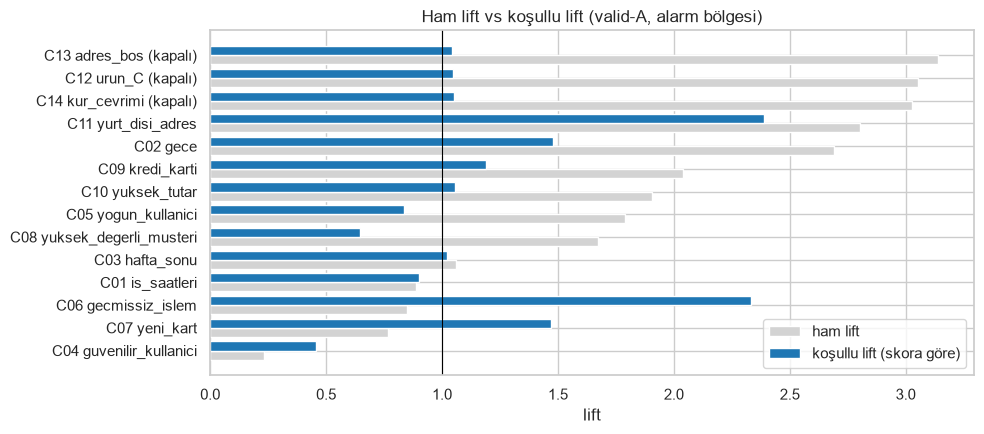

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
c = calib.sort_values("raw_lift")
y_pos = np.arange(len(c))
ax.barh(y_pos - 0.2, c["raw_lift"], height=0.4, label="ham lift", color="lightgray")
ax.barh(y_pos + 0.2, c["conditional_lift"], height=0.4, label="koşullu lift (skora göre)", color="tab:blue")
ax.axvline(1, color="black", lw=0.8)
ax.set_yticks(y_pos, [f"{i} {n}" + ("" if e else " (kapalı)") for i, n, e in zip(c.index, c["name"], c["enabled"])])
ax.set(title="Ham lift vs koşullu lift (valid-A, alarm bölgesi)", xlabel="lift")
ax.legend()
plt.tight_layout()
fig.savefig(IMG / "06_context_lift.png", dpi=120)

> **Yorum:** Ham lift ile koşullu lift arasındaki fark bu adımın en önemli bulgusu. Ürün C, adres boş ve kur çevrimi ham olarak 3 kat riskli
> ama skor bunu zaten görüyor (koşullu lift ~1,05); bunlara çarpan vermek aynı riski iki kez saymak olurdu, kanıtlarıyla kapalı
> bıraktım. Bazı kurallarda yön değişiyor: ilk işlem ham olarak daha az riskli (0,85) ama skora göre çok daha riskli (2,33), çünkü
> entity ve temporal katman geçmiş olmadığında nötr kalıyor. Yüksek değerli müşteri ham olarak riskli (1,67) ama alarm bölgesinde
> skorun beklediğinden daha az riskli (0,65). YAML'daki çarpanları bu kalibrasyon çıktısından aldım.

### 6.2 False positive azaltımı: öncesi / sonrası

İki bakış açısı:
- Sabit alarm bütçesi (analist kapasitesi sabit, en riskli %3 alarm alır): aynı sayıda alarmda daha az FP, daha çok TP.
- Sabit eşik (referans dönemde %3 alarm veren ham skor eşiği): context sonrası aynı eşikle kaç alarm ve FP çıkıyor.

In [17]:
def before_after(df, raw_col, adj_col, threshold):
    rows = {}
    for label, col in [("context öncesi", raw_col), ("context sonrası", adj_col)]:
        y, s = df[TARGET], df[col]
        m = alert_metrics(y, s, ALERT)
        fixed = s >= threshold
        rows[label] = {
            "alarm (bütçe %3)": m["alerts"], "TP": m["tp"], "FP": m["fp"],
            "precision": m["precision"], "recall": m["recall"], "PR-AUC": average_precision_score(y, s),
            "alarm (sabit eşik)": int(fixed.sum()), "FP (sabit eşik)": int((fixed & (y == 0)).sum()),
            "TP (sabit eşik)": int((fixed & (y == 1)).sum()),
        }
    t = pd.DataFrame(rows)
    t["fark"] = t["context sonrası"] - t["context öncesi"]
    return t

thr_valid = scores.loc[scores["split"] == "train", "raw_anomaly_score_valfit"].quantile(1 - ALERT)
thr_test = scores.loc[scores["split"] != "test", "raw_anomaly_score"].quantile(1 - ALERT)
pd.concat({
    "valid-B": before_after(cvB, "raw_anomaly_score_valfit", "adjusted_score_valfit", thr_valid),
    "test": before_after(ctest, "raw_anomaly_score", "adjusted_score", thr_test),
}, axis=1).round(4)

valid-B                                     test  \
                   context öncesi context sonrası      fark context öncesi   
alarm (bütçe %3)        1772.0000       1772.0000    0.0000      3543.0000   
TP                       477.0000        543.0000   66.0000       652.0000   
FP                      1295.0000       1229.0000  -66.0000      2891.0000   
precision                  0.2692          0.3064    0.0372         0.1840   
recall                     0.2314          0.2635    0.0320         0.1604   
PR-AUC                     0.1981          0.2440    0.0459         0.1130   
alarm (sabit eşik)      1326.0000       2085.0000  759.0000      4539.0000   
FP (sabit eşik)          919.0000       1502.0000  583.0000      3680.0000   
TP (sabit eşik)          407.0000        583.0000  176.0000       859.0000   

                                               
                   context sonrası       fark  
alarm (bütçe %3)         3543.0000     0.0000  
TP                        747.0000    95.0000  
FP                       2796.0000   -95.0000  
precision                   0.2108     0.0268  
recall                      0.1838     0.0234  
PR-AUC                      0.1245     0.0115  
alarm (sabit eşik)       5955.0000  1416.0000  
FP (sabit eşik)          4713.0000  1033.0000  
TP (sabit eşik)          1242.0000   383.0000

Sabit eşikte alarm sayısı artıyor çünkü yukarı çeken kurallar (ilk işlem, gece, yurt dışı...) aşağı çekenlerden fazla.
Sadece aşağı çeken kuralların sabit eşikteki etkisi, klasik anlamda "yanlış alarm azaltımı"nı gösterir:

In [18]:
down_rules = [r for r in adjuster.active_rules if r.factor < 1]
print("aşağı çeken kurallar:", [(r.id, r.name, r.factor) for r in down_rules])
rows = {}
for name, df_, raw_col, thr in [("valid-B", cvB, "raw_anomaly_score_valfit", thr_valid), ("test", ctest, "raw_anomaly_score", thr_test)]:
    adj_down = adjuster.adjust(df_, df_[raw_col], rules=down_rules)["adjusted_score"]
    y = df_[TARGET]
    before, after = df_[raw_col] >= thr, adj_down >= thr
    rows[name] = {"alarm öncesi": int(before.sum()), "alarm sonrası": int(after.sum()),
                  "FP öncesi": int((before & (y == 0)).sum()), "FP sonrası": int((after & (y == 0)).sum()),
                  "TP öncesi": int((before & (y == 1)).sum()), "TP sonrası": int((after & (y == 1)).sum())}
t = pd.DataFrame(rows).T
t["FP azalma %"] = (1 - t["FP sonrası"] / t["FP öncesi"]) * 100
t["kaybedilen TP"] = t["TP öncesi"] - t["TP sonrası"]
t.round(1)

aşağı çeken kurallar: [('C01', 'is_saatleri', 0.95), ('C04', 'guvenilir_kullanici', 0.68), ('C05', 'yogun_kullanici', 0.91), ('C08', 'yuksek_degerli_musteri', 0.8)]


,alarm öncesi,alarm sonrası,FP öncesi,FP sonrası,TP öncesi,TP sonrası,FP azalma %,kaybedilen TP
valid-B,1326,1060,919,680,407,380,26.0,27
test,4539,3821,3680,3078,859,743,16.4,116


> **Yorum:** Aynı analist kapasitesinde (en riskli %3) context, testte 95 yanlış alarmı gerçek fraud ile değiştiriyor: yakalanan fraud
> 652 -> 747, precision %18,4 -> %21,1, PR-AUC 0,113 -> 0,125. Sabit eşikte ise tüm kurallarla alarm sayısı artıyor, çünkü yukarı
> çeken kurallar daha fazla. Sadece aşağı çeken 4 kuralı (iş saati, güvenilir kullanıcı, yoğun kullanıcı, yüksek değerli müşteri)
> uygulayınca yanlış alarm valid-B'de %26, testte %16,4 azalıyor; bedeli testte 116 kaçırılan fraud. Hangisinin seçileceği bir iş
> kararı: kapasite sabitse bütçe senaryosu, alarm yükünü azaltmak öncelikse sabit eşik.

### 6.3 Ablation: her kural ne katıyor?

Her kural tek tek kapatılıp PR-AUC ve sabit bütçedeki FP değişimi ölçülüyor. Negatif ΔPR = kural faydalı (kapatınca düşüyor).

In [19]:
def ablation(df_, raw_col):
    y = df_[TARGET]
    full = adjuster.adjust(df_, df_[raw_col])["adjusted_score"]
    base_pr, base_fp = average_precision_score(y, full), alert_metrics(y, full, ALERT)["fp"]
    out = {}
    for r in adjuster.active_rules:
        others = [x for x in adjuster.active_rules if x.id != r.id]
        s = adjuster.adjust(df_, df_[raw_col], rules=others)["adjusted_score"]
        out[f"{r.id} {r.name}"] = {"ΔPR (kapatınca)": average_precision_score(y, s) - base_pr,
                                   "ΔFP@bütçe (kapatınca)": alert_metrics(y, s, ALERT)["fp"] - base_fp}
    return pd.DataFrame(out).T

pd.concat({"valid-B": ablation(cvB, "raw_anomaly_score_valfit"), "test": ablation(ctest, "raw_anomaly_score")}, axis=1).round(4)

valid-B                        \
                           ΔPR (kapatınca) ΔFP@bütçe (kapatınca)   
C01 is_saatleri                    -0.0004                  -2.0   
C02 gece                           -0.0070                  -1.0   
C03 hafta_sonu                      0.0001                  -1.0   
C04 guvenilir_kullanici            -0.0019                   1.0   
C05 yogun_kullanici                -0.0003                  -2.0   
C06 gecmissiz_islem                -0.0178                  27.0   
C07 yeni_kart                       0.0010                  -8.0   
C08 yuksek_degerli_musteri         -0.0012                  -9.0   
C09 kredi_karti                    -0.0057                   0.0   
C10 yuksek_tutar                   -0.0003                   0.0   
C11 yurt_disi_adres                -0.0021                   4.0   

                                      test                        
                           ΔPR (kapatınca) ΔFP@bütçe (kapatınca)  
C01 is_saatleri                     0.0003                   0.0  
C02 gece                           -0.0007                   5.0  
C03 hafta_sonu                      0.0001                   2.0  
C04 guvenilir_kullanici            -0.0014                   3.0  
C05 yogun_kullanici                -0.0005                   2.0  
C06 gecmissiz_islem                -0.0059                  71.0  
C07 yeni_kart                       0.0004                  -4.0  
C08 yuksek_degerli_musteri          0.0000                   8.0  
C09 kredi_karti                    -0.0014                  10.0  
C10 yuksek_tutar                   -0.0000                   0.0  
C11 yurt_disi_adres                -0.0001                   3.0

In [20]:
# kuralların kapsamı: tüm işlemlerde ve context sonrası alarm listesinde (test)
hits_test = adjuster.hits(ctest)
alerts_test = ctest["adjusted_score"] >= ctest["adjusted_score"].quantile(1 - ALERT)
pd.DataFrame({
    "kapsam (tüm işlem)": hits_test.mean(),
    "kapsam (alarm listesi)": hits_test[alerts_test].mean(),
    "fraud oranı (kural açık)": [ctest.loc[hits_test[c], TARGET].mean() for c in hits_test],
}).round(4)

,kapsam (tüm işlem),kapsam (alarm listesi),fraud oranı (kural açık)
C01,0.5920,0.4588,0.0319
C02,0.0425,0.1256,0.0737
C03,0.2512,0.4836,0.0324
C04,0.1708,0.0014,0.0103
C05,0.0844,0.4391,0.0405
C06,0.2990,0.2381,0.0319
C07,0.3175,0.0127,0.0245
C08,0.0681,0.0155,0.0449
C09,0.2309,0.7613,0.0646
C10,0.0426,0.0104,0.0525


In [21]:
# toplam çarpan sınırı seçimi (valid-B)
h = adjuster.hits(cvB)
f = pd.Series({r.id: r.factor for r in adjuster.active_rules})
total = np.exp((h[f.index].astype(float) * np.log(f)).sum(axis=1))
rows = {}
for lo, hi in [(0.5, 1.5), (0.5, 2.0), (0.3, 3.0)]:
    s = (cvB["raw_anomaly_score_valfit"] * total.clip(lo, hi)).clip(upper=1)
    rows[f"[{lo}, {hi}]"] = {"PR-AUC": average_precision_score(cvB[TARGET], s),
                             "precision@3%": alert_metrics(cvB[TARGET], s, ALERT)["precision"],
                             "sınıra takılan": ((total < lo) | (total > hi)).mean()}
pd.DataFrame(rows).T.round(4)

,PR-AUC,precision@3%,sınıra takılan
"[0.5, 1.5]",0.2423,0.3143,0.2580
"[0.5, 2.0]",0.2440,0.3064,0.0153
"[0.3, 3.0]",0.2439,0.3087,0.0001


Sınır bir güvenlik ağı: tek bir bağlamın skoru silmesini / şişirmesini engeller ve nadiren devreye girmeli.
[0,5; 1,5] işlemlerin ~%26'sını kırpıyor (ör. ilk işlem x gece kombinasyonu fiilen çalışmıyor); [0,5; 2,0] sadece ~%1,5'e dokunuyor.

> **Yorum:** En değerli kural geçmişsiz işlem: kapatınca PR valid-B'de 0,018, testte 0,006 düşüyor ve testte 71 yanlış alarm ekleniyor. Gece
> ve kredi kartı da iki dönemde de faydalı. Yeni kart (W) iki dönemde de hafif zararlı (+0,0010 / +0,0004); açık bıraktım ve
> sonucu raporladım, kaldırılması değerlendirilebilir. İş saati ve hafta sonu beklediğim gibi nötre yakın. Güvenilir kullanıcı
> kuralı işlemlerin %17'sini kapsıyor ama alarm listesinin sadece %0,14'ünü oluşturuyor; yani bu kullanıcıları listeden
> neredeyse tamamen çıkarıyor. Toplam çarpan sınırında [0,5; 2,0]'yi seçtim: [0,5; 1,5] işlemlerin %26'sını kırpıyordu, [0,5; 2,0] sadece %1,5'ine
> dokunuyor ve PR en yüksek.

In [22]:
# örnek: context kurallarının tek işlemde açıklaması
result = service.score(raw_tx, explain=False)[0]
print(f"raw {result['raw_anomaly_score']:.4f} x çarpan {result['context_factor']} = adjusted {result['adjusted_score']:.4f} "
      f"(risk yüzdeliği {result['risk_percentile']:.5f})")
for a in result["context_adjustments"]:
    print(f"  {a['id']} {a['name']} x{a['factor']}: {a['condition']} -> {a['reason']}")

raw 0.4593 x çarpan 1.22 = adjusted 0.5604 (risk yüzdeliği 0.99993)
  C02 gece x1.22: is_night = 1 -> Yerel 00-06 arası hacim düşük, fraud oranı ~2,7 kat; temporal katmanın nadir saat bileşeni bunu zayıf yakalıyor


## 7. Rule engine (Adım 7)

Context skoru düzeltir; rule engine iş kararı verir (BLOCK / REVIEW / FLAG / ALLOW). Kurallar `config/rules.yaml`'da (JSON da desteklenir),
koşul dili context motoruyla ortak. Anomali skoru kurallara alan olarak girer (`risk_percentile`), böylece skor da öncelikli bir kural gibi
çakışma çözümüne katılır.

Tasarım ilkeleri
- Öncelik bantları: BLOCK 90-100, REVIEW 65-89, beyaz liste 60, FLAG 40-59 (FLAG skorun REVIEW kararını ezemez)
- BLOCK sadece yüksek isabette; yanlış blok müşteriyi doğrudan etkiler
- Ek isabet testi: kural, skorun %3 bütçesi dışına skorun marjinal isabetinden (~%11) daha isabetli alarm ekliyorsa REVIEW, eklemiyorsa FLAG

In [23]:
import tempfile
from pathlib import Path

import yaml

from fraud_platform.rules.engine import RuleEngine

rule_engine = RuleEngine(settings.rules.rules_file, settings.rules.base_risk_field)
print(f"strateji: {rule_engine.ruleset.conflict_strategy} | aktif kural: {len(rule_engine.rules)} / {len(rule_engine.ruleset.rules)}")
pd.DataFrame([{"id": r.id, "ad": r.name, "öncelik": r.priority, "aksiyon": r.action, "koşul": describe(r.condition),
               "risk_delta": r.risk_delta, "politika": r.policy_ref, "aktif": r.enabled} for r in rule_engine.ruleset.rules]).set_index("id")

strateji: priority_then_severity | aktif kural: 12 / 14


,ad,öncelik,aksiyon,koşul,risk_delta,politika,aktif
id,,,,,,,
R001,Velocity patlaması,100,BLOCK,(tx_count_1h ≥ 10 VE user_tx_count < 100),0.30,FP-03,True
R002,Çok yüksek anomali skoru,95,BLOCK,(risk_percentile ≥ 0.999 VE user_tx_count < 100),0.20,FP-01,True
R003,Gece veya yurt dışı + yüksek tutar,85,REVIEW,(TransactionAmt ≥ 500 VE (is_night = 1 VEYA is_foreign_address = 1)),0.15,FP-15,True
R004,Riskli e-posta domaini,80,REVIEW,"P_emaildomain ∈ ['protonmail.com', 'mail.com', 'outlook.es']",0.10,FP-18,True
R005,Yüksek anomali skoru (alarm bütçesi),70,REVIEW,risk_percentile ≥ 0.97,0.05,FP-01,True
R006,"Güvenilir müşteri, düşük tutar",60,ALLOW,(card_age_days ≥ 180 VE days_since_first_tx ≥ 30 VE is_new_device_for_user = 0 VE TransactionAmt < 100),-0.10,FP-20,True
R007,Cihaz paylaşımı (kart test) + yüksek skor,58,FLAG,(device_n_cards ≥ 5 VE risk_percentile ≥ 0.9),0.10,FP-12,True
R008,Velocity yüksek,56,FLAG,tx_count_1h ≥ 5,0.10,FP-03,True
R009,24 saatlik harcama patlaması,54,FLAG,(amount_sum_24h ≥ 2000 VE tx_count_24h ≥ 5),0.10,FP-04,True


In [24]:
def rule_period(split):
    suffix = "_valfit" if split == "valid" else ""
    cols = [ID, f"risk_percentile{suffix}", f"adjusted_score{suffix}"]
    sc = scores.loc[scores["split"] == split, cols].rename(
        columns={f"risk_percentile{suffix}": "risk_percentile", f"adjusted_score{suffix}": "adjusted_score"})
    return features.reset_index().merge(sc, on=ID)

rvalid, rtest = rule_period("valid"), rule_period("test")
budget = settings.rules.review_budget
stats_valid = rule_engine.stats(rvalid, TARGET, budget_threshold=budget)
stats_valid[["name", "enabled", "action", "priority", "fired", "coverage", "precision", "recall", "incremental_precision", "won", "overridden"]].round(4)

,name,enabled,action,priority,fired,coverage,precision,recall,incremental_precision,won,overridden
id,,,,,,,,,,,
R001,Velocity patlaması,True,BLOCK,100,74,0.0006,0.5676,0.0091,0.1818,74,0
R002,Çok yüksek anomali skoru,True,BLOCK,95,366,0.0031,0.6913,0.0549,NaN,343,23
R003,Gece veya yurt dışı + yüksek tutar,True,REVIEW,85,181,0.0015,0.2210,0.0087,0.2012,178,3
R004,Riskli e-posta domaini,True,REVIEW,80,242,0.0020,0.2645,0.0139,0.2140,239,3
R005,Yüksek anomali skoru (alarm bütçesi),True,REVIEW,70,5045,0.0427,0.2896,0.3169,NaN,4604,441
R006,"Güvenilir müşteri, düşük tutar",True,ALLOW,60,10845,0.0918,0.0119,0.0280,0.0116,10841,4
R007,Cihaz paylaşımı (kart test) + yüksek skor,True,FLAG,58,5279,0.0447,0.1872,0.2143,0.0768,3130,2149
R008,Velocity yüksek,True,FLAG,56,739,0.0063,0.1705,0.0273,0.0574,271,468
R009,24 saatlik harcama patlaması,True,FLAG,54,550,0.0047,0.1636,0.0195,0.0826,325,225


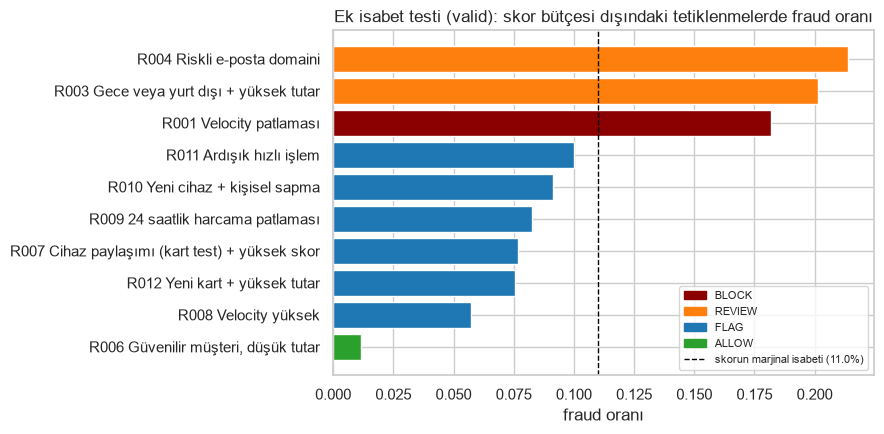

In [25]:
marginal = rvalid.loc[(rvalid["risk_percentile"] < budget) & (rvalid["risk_percentile"] >= 2 * budget - 1), TARGET].mean()
s = stats_valid[stats_valid["enabled"] & stats_valid["incremental_precision"].notna()].sort_values("incremental_precision")
colors = s["action"].map({"BLOCK": "darkred", "REVIEW": "tab:orange", "FLAG": "tab:blue", "ALLOW": "tab:green"})
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh([f"{i} {n}" for i, n in zip(s.index, s["name"])], s["incremental_precision"], color=colors)
ax.axvline(marginal, color="black", ls="--", lw=1, label=f"skorun marjinal isabeti ({marginal:.1%})")
ax.set(title="Ek isabet testi (valid): skor bütçesi dışındaki tetiklenmelerde fraud oranı", xlabel="fraud oranı")
from matplotlib.patches import Patch
handles = [Patch(color=c, label=a) for a, c in [("BLOCK", "darkred"), ("REVIEW", "tab:orange"), ("FLAG", "tab:blue"), ("ALLOW", "tab:green")]]
ax.legend(handles=[*handles, ax.get_lines()[0]], loc="lower right", fontsize=8)
plt.tight_layout()
fig.savefig(IMG / "07_rule_incremental.png", dpi=120)

> **Yorum:** Grafikteki çizgi skorun bütçe dışındaki marjinal isabeti (%11). Çizginin sağında kalan kurallar (riskli e-posta %21,4, gece /
> yurt dışı + yüksek tutar %20,1, velocity patlaması %18,2) bütçeye skorun ekleyebileceğinden daha isabetli alarm ekliyor; bunlara
> REVIEW ya da BLOCK verdim. Solda kalanlar (cihaz paylaşımı %7,7, velocity %5,7, harcama patlaması %8,3, yeni cihaz %9,1, yeni
> kart %7,6) FLAG: analiste iş yüklemiyorlar, izleme için. Beyaz liste kuralının isabeti %1,2, ortalamanın üçte biri; doğru
> müşterileri kapsıyor. En çok alarm üreten ve en isabetli REVIEW / BLOCK kaynağı skor kuralları (R002, R005).

### 7.1 Karar dağılımı ve skorla kıyas

Asıl soru: kurallar, aynı alarm hacminde skorun tek başına yapacağından daha iyi mi? (alarm = REVIEW + BLOCK)

In [26]:
def decision_vs_score(df, strategy=None, engine=rule_engine):
    out = engine.evaluate_batch(df, strategy)
    y = df[TARGET]
    alert = out["decision"].isin(["REVIEW", "BLOCK"])
    top = df["adjusted_score"].rank(ascending=False, method="first") <= alert.sum()
    block = out["decision"] == "BLOCK"
    return {"alarm": int(alert.sum()), "hacim": alert.mean(), "precision": y[alert].mean(), "recall": y[alert].sum() / y.sum(),
            "skor_aynı_hacim_precision": y[top].mean(), "skor_aynı_hacim_recall": y[top].sum() / y.sum(),
            "BLOCK": int(block.sum()), "BLOCK_precision": y[block].mean()}

display(pd.concat({"valid": rule_engine.decision_summary(rvalid, TARGET), "test": rule_engine.decision_summary(rtest, TARGET)}, axis=1).round(4))
pd.DataFrame({"valid": decision_vs_score(rvalid), "test": decision_vs_score(rtest)}).T.round(4)

valid                                   test                     \
               n   share fraud_rate fraud_share       n   share fraud_rate   
decision                                                                     
BLOCK        417  0.0035     0.6763      0.0612     416  0.0035     0.3413   
REVIEW      5021  0.0425     0.2507      0.2730    5895  0.0499     0.1922   
FLAG        7204  0.0610     0.0755      0.1180    6679  0.0565     0.0594   
ALLOW     105466  0.8930     0.0240      0.5478  105118  0.8900     0.0228   

                      
         fraud_share  
decision              
BLOCK         0.0349  
REVIEW        0.2788  
FLAG          0.0977  
ALLOW         0.5886

,alarm,hacim,precision,recall,skor_aynı_hacim_precision,skor_aynı_hacim_recall,BLOCK,BLOCK_precision
valid,5438.0,0.0460,0.2834,0.3342,0.2764,0.3260,417.0,0.6763
test,6311.0,0.0534,0.2020,0.3137,0.2044,0.3174,416.0,0.3413


### 7.2 Çakışma çözüm stratejileri

Strateji config'ten seçilir (`conflict_strategy`) ve API'de çağrı başına değiştirilebilir:
`priority_then_severity` (öncelik, eşitlikte ağır aksiyon), `most_severe` (ağır aksiyon, eşitlikte öncelik), `first_match` (dosya sırası).

Bantlı tasarımda öncelik sırası aksiyon ağırlığıyla aynı ve dosya önceliğe göre sıralı, bu yüzden üç strateji aynı kararı veriyor:
kural seti strateji seçimine dayanıklı. Farkı görmek için iki kasıtlı "bozuk" varyant: (a) dosya sırası ters, (b) beyaz liste önceliği 99.

In [27]:
def variant_engine(mod):
    raw = yaml.safe_load(settings.rules.rules_file.read_text(encoding="utf-8"))
    mod(raw)
    p = Path(tempfile.mkdtemp()) / "rules.yaml"
    p.write_text(yaml.safe_dump(raw, allow_unicode=True), encoding="utf-8")
    return RuleEngine(p)

def reverse_order(raw):
    raw["rules"] = raw["rules"][::-1]

def whitelist_99(raw):
    next(r for r in raw["rules"] if r["action"] == "ALLOW")["priority"] = 99

rows = {}
for vname, eng in [("bantlı (mevcut)", rule_engine), ("(a) dosya sırası ters", variant_engine(reverse_order)),
                   ("(b) beyaz liste öncelik 99", variant_engine(whitelist_99))]:
    for st in ["priority_then_severity", "most_severe", "first_match"]:
        rows[(vname, st)] = decision_vs_score(rvalid, st, engine=eng)
pd.DataFrame(rows).T[["alarm", "precision", "recall", "BLOCK"]].round(4)

alarm  precision  recall  \
bantlı (mevcut)            priority_then_severity  5438.0     0.2834  0.3342   
                           most_severe             5438.0     0.2834  0.3342   
                           first_match             5438.0     0.2834  0.3342   
(a) dosya sırası ters      priority_then_severity  5438.0     0.2834  0.3342   
                           most_severe             5438.0     0.2834  0.3342   
                           first_match             2893.0     0.2357  0.1479   
(b) beyaz liste öncelik 99 priority_then_severity  5434.0     0.2830  0.3336   
                           most_severe             5438.0     0.2834  0.3342   
                           first_match             5438.0     0.2834  0.3342   

                                                   BLOCK  
bantlı (mevcut)            priority_then_severity  417.0  
                           most_severe             417.0  
                           first_match             417.0  
(a) dosya sırası ters      priority_then_severity  417.0  
                           most_severe             417.0  
                           first_match               0.0  
(b) beyaz liste öncelik 99 priority_then_severity  417.0  
                           most_severe             417.0  
                           first_match             417.0

(a)'da `first_match` dosyanın başındaki FLAG / ALLOW kurallarını önce gördüğü için hiç BLOCK kalmıyor (417 -> 0), recall %33'ten %15'e düşüyor.
(b)'de `priority_then_severity` beyaz listeyi REVIEW/BLOCK'un üstüne çıkarıyor; bu veride etkisi küçük (güvenilir müşterinin küçük işlemleri
nadiren yüksek riskli) ama prensipte bir güvenilir müşteri hesabı ele geçirildiğinde skor alarmı susturulur. `most_severe` ağır aksiyonu korur.
Bantlı öncelik + önceliğe göre sıralı dosya bu iki tuzağı da kapatıyor.

> **Yorum:** Kurallar aynı alarm hacminde skoru valid'de geçiyor (precision %28,3 vs %27,6, recall %33,4 vs %32,6), testte başa baş (%20,2 vs
> %20,4). Kuralların asıl katkısı kararı ayrıştırmak: BLOCK işlemlerin %0,35'i ve isabeti valid'de %67,6, testte %34,1; REVIEW
> %4-5; FLAG izleme. Üç çakışma stratejisi bu kural setinde aynı kararı veriyor, çünkü öncelik bantları aksiyon ağırlığıyla uyumlu
> ve dosya önceliğe göre sıralı. Bozuk varyantlar tuzakları gösteriyor: dosya sırası ters ve first_match ile hiç BLOCK kalmıyor
> (417 -> 0), recall %33'ten %15'e düşüyor; beyaz listeye 99 öncelik verilince priority_then_severity beyaz listeyi alarmların
> üstüne çıkarıyor. Bu veride etkisi 4 alarm, ama ele geçirilmiş güvenilir bir hesapta alarm susturulmuş olur.

### 7.3 Test dönemi olayı: meşru yüksek hacimli entity

İlk kural setinde test döneminde BLOCK isabeti %67,6'dan (valid) %8,3'e düştü. Sebep tek bir entity: 1.414 işlem, ProductCD S,
17 farklı tutar, hiç fraud yok (abonelik / entegrasyon hesabına benziyor). Mutlak velocity eşiği ve skor tabanlı BLOCK onu toplu blokluyordu.

Düzeltme (`user_tx_count < 100` koruması) bir alan ilkesine dayanıyor: yerleşik yüksek hacimli entity'nin velocity'si kendisi için olağan,
otomatik blok yerine insan incelemesine (REVIEW) düşmeli. Valid'deki gerçek fraud patlamalarının hepsi <= 70 geçmiş işlemli kullanıcılarda;
koruma valid'de hiçbir kararı değiştirmiyor. Sorun testte bulunduğu için düzeltme sonrası test sonucu iyimserdir; iki durum da raporlanıyor.

In [28]:
heavy_uid = rtest.loc[rtest["tx_count_1h"] >= 10, "uid"].value_counts().index[0]
h = features.reset_index().query("uid == @heavy_uid")
print(f"entity {heavy_uid}: {len(h)} işlem, ProductCD {h['ProductCD'].value_counts().to_dict()}, "
      f"{h['TransactionAmt'].nunique()} farklı tutar, fraud oranı {h[TARGET].mean():.3f}")

raw_rules = yaml.safe_load(settings.rules.rules_file.read_text(encoding="utf-8"))
for r in raw_rules["rules"]:
    if r["id"] in ("R001", "R002"):
        r["condition"] = r["condition"]["all"][0]          # korumayı kaldır
tmp = Path(tempfile.mkdtemp()) / "rules_no_guard.yaml"
tmp.write_text(yaml.safe_dump(raw_rules, allow_unicode=True), encoding="utf-8")
no_guard = RuleEngine(tmp)

pd.DataFrame({
    ("valid", "korumasız"): decision_vs_score(rvalid, engine=no_guard), ("valid", "korumalı"): decision_vs_score(rvalid),
    ("test", "korumasız"): decision_vs_score(rtest, engine=no_guard), ("test", "korumalı"): decision_vs_score(rtest),
}).T[["BLOCK", "BLOCK_precision", "alarm", "precision", "recall"]].round(4)

entity 15775_330_129: 1414 işlem, ProductCD {'S': 1414}, 17 farklı tutar, fraud oranı 0.000


BLOCK  BLOCK_precision   alarm  precision  recall
valid korumasız   417.0           0.6763  5438.0     0.2834  0.3342
      korumalı    417.0           0.6763  5438.0     0.2834  0.3342
test  korumasız  1718.0           0.0827  6311.0     0.2020  0.3137
      korumalı    416.0           0.3413  6311.0     0.2020  0.3137

> **Yorum:** Bu olay projedeki en öğretici an oldu. Validasyonda çok iyi görünen BLOCK kuralları, testte tek bir meşru yüksek hacimli hesap
> yüzünden %8,3 isabete düştü. Mutlak bir velocity eşiği, yeni ortaya çıkan meşru bir hacim örüntüsüne karşı kırılgan. Koruma
> (user_tx_count < 100) valid'de hiçbir kararı değiştirmiyor, testte BLOCK sayısını 1.718'den 416'ya indiriyor ve hiç fraud
> kaybettirmiyor. Sorunu testte bulduğum için bu sonuç iyimser; bunu açıkça yazdım. Üretimde benzer durumlar için BLOCK hacmini
> izleyen bir devre kesici (FP-41) ve onaylı yüksek hacimli hesap listesi (FP-25) gerekir.

### 7.4 Açıklama, JSON desteği ve dinamik yeniden yükleme

In [29]:
# çakışma örneği: birden çok kural tetiklenen bir test işlemi
batch = rule_engine.evaluate_batch(rtest)
example = rtest.loc[(batch["n_fired"] >= 3) & (rtest[TARGET] == 1)].iloc[0]
print(json.dumps(rule_engine.evaluate(example), indent=2, ensure_ascii=False, default=str))

{
  "final_decision": "REVIEW",
  "final_risk": 1.0,
  "base_risk": 0.9811,
  "winning_rule": "R005",
  "decision_reason": "priority_then_severity: kazanan kural R005 (Yüksek anomali skoru (alarm bütçesi), öncelik 70, REVIEW); tetiklenen 3 kural",
  "conflict_strategy": "priority_then_severity",
  "fired_rules": [
    {
      "id": "R005",
      "name": "Yüksek anomali skoru (alarm bütçesi)",
      "category": "skor",
      "priority": 70,
      "action": "REVIEW",
      "risk_delta": 0.05,
      "policy_ref": "FP-01",
      "condition": "risk_percentile ≥ 0.97",
      "matched_values": {
        "risk_percentile": 0.9811
      },
      "explanation": "Anomali skoru en riskli %3'te (risk yüzdeliği 0.9811)"
    },
    {
      "id": "R007",
      "name": "Cihaz paylaşımı (kart test) + yüksek skor",
      "category": "cihaz",
      "priority": 58,
      "action": "FLAG",
      "risk_delta": 0.1,
      "policy_ref": "FP-12",
      "condition": "(device_n_cards ≥ 5 VE risk_percentile ≥ 0.9)

In [30]:
# aynı kurallar JSON olarak: sonuç birebir aynı
json_path = Path(tempfile.mkdtemp()) / "rules.json"
json_path.write_text(json.dumps(yaml.safe_load(settings.rules.rules_file.read_text(encoding="utf-8")), ensure_ascii=False), encoding="utf-8")
print("YAML == JSON:", RuleEngine(json_path).evaluate(example) == rule_engine.evaluate(example))

# reload: dosyaya kural eklenir, kod değişmeden devreye girer
extra = yaml.safe_load(settings.rules.rules_file.read_text(encoding="utf-8"))
extra["rules"].append({"id": "R099", "name": "Deneme: çok yüksek tutar", "priority": 88, "action": "REVIEW",
                       "condition": {"field": "TransactionAmt", "op": "gte", "value": 3000},
                       "explanation": "{TransactionAmt:.2f} USD", "policy_ref": "FP-15"})
dyn = Path(tempfile.mkdtemp()) / "rules.yaml"
dyn.write_text(yaml.safe_dump(raw_rules, allow_unicode=True), encoding="utf-8")
eng = RuleEngine(dyn)
before = len(eng.rules)
dyn.write_text(yaml.safe_dump(extra, allow_unicode=True), encoding="utf-8")
print(f"reload: {before} -> {eng.reload()} aktif kural")

YAML == JSON: True
reload: 12 -> 13 aktif kural


## 8. Özet

Üretilen çıktılar: `artifacts/detectors/*.joblib`, `aggregator.joblib`, `layer_scores.parquet`, `layer_metrics.json`,
`profile_store.parquet`, `config/context_rules.yaml`, `config/rules.yaml`

- Katmanlar: en güçlü tek katman column; katmanlar tamamlayıcı (721 test fraud'unu sadece tek bir katman yakalıyor). Valid -> test PR düşüşü drift; ROC kararlı.
- Train/serve: profil deposu + aynı pipeline, 200 işlemde 0 fark.
- Birleştirme: kuyruk-log normalizasyon ve performansa orantılı ağırlık; ham birleşim PR'de column'u geçmiyor, ROC'ta geçiyor.
- Context: koşullu lift ile kalibre edilmiş 11 kural; aynı kapasitede testte +95 fraud / -95 yanlış alarm, PR 0,113 -> 0,125 (column'u da geçti).
- Kurallar: öncelik bantları, ek isabet testi, skor da bir kural; aynı hacimde skordan valid'de daha iyi, testte başa baş; BLOCK isabeti valid %67,6 / test %34,1.
- Ders: test dönemindeki meşru yüksek hacimli hesap; mutlak eşikli kurallar için koruma ve izleme gerekli.